# Install dependencies

In [ ]:
!pip install -q datasets timm pytorch-lightning torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 32.0 MB/s eta 0:00:00


In [ ]:
!pip install onnx onnxscript


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.0/683.0 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 13.4 MB/s eta 0:00:00


In [ ]:
!nvidia-smi

# Imports

In [ ]:
import torch
import timm
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
import pytorch_lightning as pl
from PIL import Image
import matplotlib.pyplot as plt
import importlib
import onnxscript



# Food101 dataset from Hugging Face

In [ ]:
dataset = load_dataset("ethz/food101")  # splits: train / validation

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

data/validation-00000-of-00003.parquet:   0%|          | 0.00/423M [00:00<?, ?B/s]

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

In [ ]:
class_names = dataset["train"].features["label"].names

id2label = {i: name for i, name in enumerate(class_names)}
label2id = {name: i for i, name in id2label.items()}

num_classes = len(class_names)

print(num_classes)

101


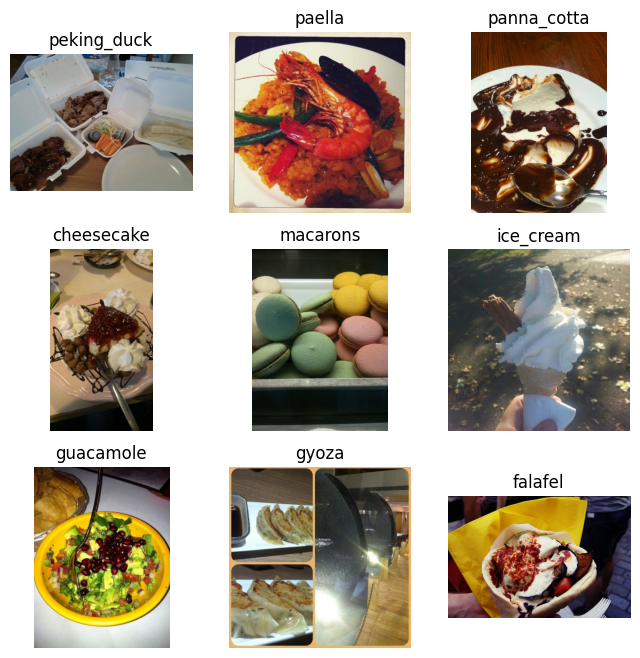

In [ ]:
# view samples from dataset
sample = dataset["train"].shuffle(seed=42).select(range(9))

plt.figure(figsize=(8,8))
for i, item in enumerate(sample):
    plt.subplot(3,3,i+1)
    plt.imshow(item["image"])
    plt.title(dataset["train"].features["label"].int2str(item["label"]))
    plt.axis("off")
plt.show()


# Transformers + Dataset Wrapper

In [ ]:
image_size = 224

train_tfms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

val_tfms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

class HFImageDataset(torch.utils.data.Dataset):
    def __init__(self, hf_split, transform=None):
        self.ds = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img = item["image"]          # this is a PIL Image
        label = item["label"]

        # make sure 3-channel RGB
        if img.mode != "RGB":
            img = img.convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


train_ds = HFImageDataset(dataset["train"], transform=train_tfms)
val_ds = HFImageDataset(dataset["validation"], transform=val_tfms)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
for i in range(5):
    img = dataset["train"][i]["image"]
    print(i, img.mode, img.size)


0 RGB (384, 512)
1 RGB (512, 512)
2 RGB (512, 383)
3 RGB (512, 348)
4 RGB (512, 512)


# Use timm to get CNN/ ViT/ hybrid models


In [ ]:
model = timm.create_model(
    "resnet50",          # ← change this string to swap architectures
    pretrained=True,
    num_classes=num_classes,
)


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

# Lightning Module to abstract training

In [ ]:
class FoodClassifier(pl.LightningModule):
    def __init__(self, backbone_name: str, num_classes: int, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=num_classes,
        )
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"}}


# Training variants with different backbones

In [ ]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

def train_backbone(backbone_name, max_epochs=10):
    model = FoodClassifier(backbone_name=backbone_name, num_classes=num_classes, lr=1e-4)

    checkpoint_cb = ModelCheckpoint(
        monitor="val_acc",
        mode="max",
        save_top_k=1,
        filename=f"{backbone_name}-{{epoch:02d}}-{{val_acc:.3f}}",
    )
    early_stop_cb = EarlyStopping(monitor="val_acc", mode="max", patience=3)

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        callbacks=[checkpoint_cb, early_stop_cb],
        precision="16-mixed",  # mixed precision for speed
    )

    trainer.fit(model, train_dl, val_dl)
    return trainer, model

# 1) CNN
trainer_cnn, model_cnn = train_backbone("resnet50", max_epochs=5)

# # 2) ViT
# trainer_vit, model_vit = train_backbone("vit_base_patch16_224", max_epochs=10)

# # 3) Hybrid-ish (ConvNeXt / CoAtNet style)
# trainer_hybrid, model_hybrid = train_backbone("convnext_base", max_epochs=10)


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


# Loading the trained model from .ckpt

In [ ]:
ckpt_path = "/content/lightning_logs/version_0/checkpoints/resnet50-epoch=04-val_acc=0.805.ckpt"

model = FoodClassifier.load_from_checkpoint(
    ckpt_path,
    backbone_name="resnet50",
    num_classes=num_classes,
    lr=1e-4,
)
model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")


FoodClassifier(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act2): ReLU(inplace=True)
        (aa): Identity()
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05,

In [ ]:
from PIL import Image
import torch
from torchvision import transforms

image_size = 224
val_tfms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


In [ ]:
img = Image.open("/content/dumplings.jpeg").convert("RGB")
x = val_tfms(img).unsqueeze(0)  # [1, 3, 224, 224]
x = x.to("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
with torch.no_grad():
    logits = model(x)
    pred = logits.argmax(dim=1).item()

print("Predicted class:", id2label[pred])


Predicted class: gyoza


## full code for .ckpt

In [ ]:
import torch
from PIL import Image
from torchvision import transforms

# ---------- Load checkpoint ----------
ckpt_path = "/content/lightning_logs/version_0/checkpoints/resnet50-epoch=04-val_acc=0.805.ckpt"

model = FoodClassifier.load_from_checkpoint(
    ckpt_path,
    backbone_name="resnet50",
    num_classes=num_classes,
    lr=1e-4,
)
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# ---------- Preprocess ----------
val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

img_path = "/content/pizza.jpeg"
img = Image.open(img_path).convert("RGB")
x = val_tfms(img).unsqueeze(0).to(device)

# ---------- Inference ----------
with torch.no_grad():
    logits = model(x)
    pred = logits.argmax(1).item()

print("Predicted class:", id2label[pred])


Predicted class: pizza


# ONNX

In [ ]:
import torch

# Reload fresh to be safe
model = FoodClassifier.load_from_checkpoint(
    ckpt_path,
    backbone_name="resnet50",
    num_classes=num_classes,
    lr=1e-4,
)
model.eval()
model.cpu()

dummy_input = torch.randn(1, 3, 224, 224)

# Use legacy exporter
torch.onnx.export(
    model,
    dummy_input,
    "food101_legacy.onnx",
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    training=torch.onnx.TrainingMode.EVAL,
    dynamo=False,  # ← Bypass dynamo, use legacy TorchScript exporter
)

print("Legacy export complete!")

/tmp/ipython-input-3767172457.py:16: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Legacy export complete!


In [ ]:
session = ort.InferenceSession("food101_legacy.onnx")

img = Image.open("/content/dumplings.jpeg").convert("RGB")
x = val_tfms(img).unsqueeze(0).numpy()

onnx_logits = session.run(None, {"input": x})[0]

with torch.no_grad():
    pt_logits = model(torch.from_numpy(x)).numpy()

print(f"PyTorch: {id2label[pt_logits.argmax()]}")
print(f"ONNX:    {id2label[np.argmax(onnx_logits)]}")
print(f"Max diff: {np.abs(pt_logits - onnx_logits).max():.6f}")

PyTorch: gyoza
ONNX:    gyoza
Max diff: 0.000010


# Saving ONNX and Labels

In [ ]:
# 1. Download the ONNX model
from google.colab import files
files.download("food101_legacy.onnx")

# 2. Save and download the class mapping
import json
with open("id2label.json", "w") as f:
    json.dump(id2label, f)
files.download("id2label.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Later usage (anywhere)

In [ ]:
import json
import numpy as np
import onnxruntime as ort
from PIL import Image
from torchvision import transforms

# Load model and class mapping
session = ort.InferenceSession("food101_legacy.onnx")
with open("id2label.json") as f:
    id2label = json.load(f)
    id2label = {int(k): v for k, v in id2label.items()}  # Keys back to int

# Preprocessing (must match training)
val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predict(image_path):
    img = Image.open(image_path).convert("RGB")
    x = val_tfms(img).unsqueeze(0).numpy()
    logits = session.run(None, {"input": x})[0]
    return id2label[int(np.argmax(logits))]